# Impoprt Libraries

In [1]:
import my_data_manager as mdm # Replace with your own to load personalized data
import astro_utils as au
import cluster_utils as cu
import plot_maker as pm
import clustering_methods as clustering

import matplotlib.pyplot as plt
import random
import numpy as np

In [62]:
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [2]:
#Replace with your data
mocks_path = "SPLUS_clean_halos"
raw_cats = mdm.load_data(mocks_path)

print(raw_cats[0].head())

  # galaxyId haloId haloId_dor ra dec z_app log(m_200)
0  140005829421049.0 140005829198429.0 0.0 97.853...  
1  140005829372198.0 140005829198429.0 0.0 97.658...  
2  140005829372259.0 140005829198429.0 0.0 97.651...  
3  140005829372291.0 140005829198429.0 0.0 97.683...  
4  140005829372318.0 140005829198429.0 0.0 97.617...  


# Scrub Data

In [3]:
#Replace as necesary

cats = mdm.fix_columns(raw_cats)

members_count_threshold = 300
cats_subset = [cat for cat in cats if len(cat) > members_count_threshold]

sample_size = 30
cats_samples = random.sample(cats_subset, sample_size)

# Plot the Data

In [4]:
import importlib

importlib.reload(pm)

<module 'plot_maker' from '/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/plot_maker.py'>

[]

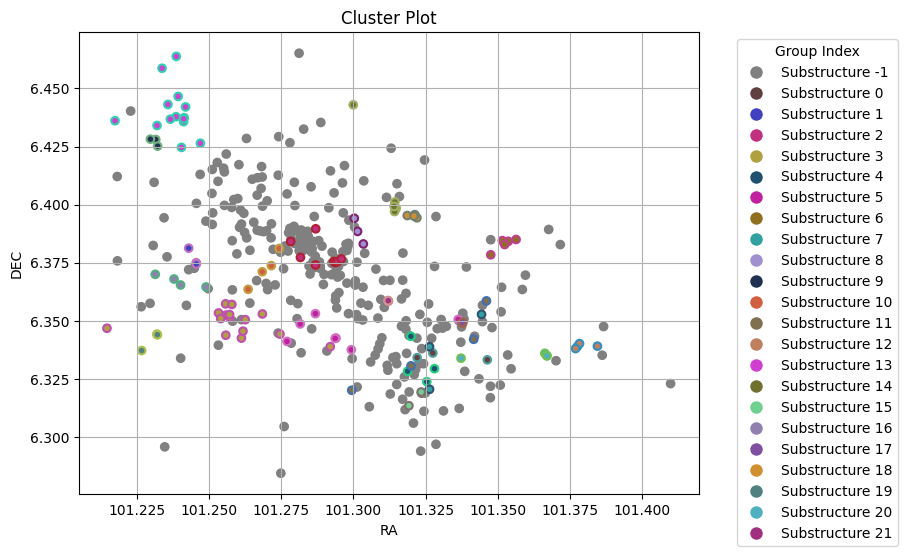

In [5]:
r_sample = cats_samples[random.randint(0, len(cats_samples)-1)]

X_data = r_sample.iloc[:,3].values
Y_data = r_sample.iloc[:,4].values
og_labels = r_sample.iloc[:,2].values

fig, ax = pm.cluster_plot_2D(X_data, Y_data, og_labels, x_axis_nature="RA", y_axis_nature="DEC", cluster_nature="Substructure")

plt.plot()
    

# Select Algorithms

In [6]:
algorithms = {}


algorithms['GMM'] = clustering.run_GMM
algorithms['DBSCAN'] = clustering.run_DBSCAN
algorithms['HDBSCAN'] = clustering.run_HDBSCAN
algorithms['Optics'] = clustering.run_OPTICS
algorithms['Kmeans'] = clustering.run_Kmeans
algorithms['Aglomerative'] = clustering.run_Aglomerative_Clustering
algorithms['Affinity'] = clustering.run_Affinity_Propagation

# Set Parameters

In [7]:
params = {
    "max_clusters" : 40,
    "covariance_type" : 'full',
    "min_cluster_size" : 5,
    "random_state" : 0,
    "min_eps" : 0.5,
    "max_eps" : np.inf,
    "linkage" : 'ward',
    "clustering_threshold" : 0.5,
    "key_point" : 'location',
    "max_iter" : 1000
}

# Run Algorithms

In [8]:
alg_labels = {}

for alg in algorithms.keys():
    alg_labels[alg] = []

for sample in cats_samples:
    
    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    
    data = np.column_stack((X_data, Y_data))
    
    for alg in algorithms.keys():
        labels, probs, clusteres = algorithms[alg](data, params)
        alg_labels[alg].append(labels)
    
    
    

/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be remov

Add DS+ as benchmarking

In [9]:
from ds_plus import milaDS

alg_labels["DS+"] = []

for sample in cats_samples:
    
    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    Z_data = sample.iloc[:,5].values
    
    x_center = (min(X_data) + max(X_data))/2
    y_center = (min(Y_data) + max(Y_data))/2

    X_Kpc, Y_Kpc = au.gal_Mpc_coords(X_data, Y_data, Z_data, x_center, y_center)
    X_Kpc *= 1000
    Y_Kpc *= 1000
    
    Z_clus = np.mean(Z_data);
    V_data = au.los_vel(Z_data, Z_clus)

    galaxy_info, grouping, summary = milaDS.DSp_groups(X_data, Y_data, V_data, Z_clus)
    
    labels = np.array([row[8] for row in grouping]) #9th column corresponds to the group

    alg_labels["DS+"].append(labels)


/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ds_plus/tools_DS.py:382: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  locsDF = pd.concat([locsDF, iterDF1])
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ds_plus/tools_DS.py:395: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evalDF = pd.concat([evalDF, iterDF2])
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ds_plus/tools_DS.py:382: FutureWarning: The behavior of DataFrame concatenation w

Add CALSAGOS to compare

In [10]:
alg_labels["CALSAGOS"] = []

from calsagos import lagasu
from calsagos import utils
from calsagos import clumberi
from astropy.stats import biweight_location

import importlib
importlib.reload(clumberi)
importlib.reload(lagasu)

#- S-PLUS mock cosmology
H_mock = 67.3
Omega_L_mock = 0.685
Omega_m_mock = 0.315

#-- GENERAL PARAMETERS
range_cuts = 15 # -- number of Gaussians to be fitted in the CLUMBERI and LAGASU implementation
n_galaxies = 3 # -- number of minimum of galaxies that a group or substructure must have

for sample in cats_samples:

    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    Z_data = sample.iloc[:,5].values

    x_cluster = biweight_location(X_data)
    y_cluster = biweight_location(Y_data)
    Z_clus = biweight_location(Z_data);
    
    cluster_mass = sample.iloc[:,5].values[0]
    
    id_galaxy = indexes = np.arange(len(sample) + 1)
    
    #-- defining the cluster radius
    r200_kpc = utils.calc_radius_finn(cluster_mass, Z_clus, H_mock, Omega_L_mock, Omega_m_mock, "kiloparsec")

    #-- converting the radius in kpc to a radius in angular units
    #-- NOTE: if the user has an estimate of the r200 of the cluster it is not necessary to calculate this quantity
    r200_degree = utils.convert_kpc_to_angular_distance(r200_kpc, Z_clus, H_mock, Omega_m_mock, "degrees") 

    #-- select cluster members
    cluster_members = clumberi.clumberi(id_galaxy, X_data, Y_data, Z_data, Z_clus, x_cluster, y_cluster, range_cuts)

    # -- defining output parameters from clumberi
    id_member = cluster_members[0]
    ra_member = cluster_members[1]
    dec_member = cluster_members[2]
    redshift_member = cluster_members[3]

    #-- estimating the galaxy separation of galaxies in the cluster sample to be used as input in lagasu
    knn_distance = utils.calc_knn_galaxy_distance(ra_member, dec_member, n_galaxies)

    #-- determining the distance to the k-nearest neighbor of each galaxy in the cluster
    knn_galaxy_distance = knn_distance[0]

    typical_separation = utils.best_eps_dbscan(id_member, knn_galaxy_distance)

    #-- Assign galaxies to each substructures
    label_candidates = lagasu.lagasu(id_galaxy, X_data, Y_data, Z_data, 
                           range_cuts, typical_separation, n_galaxies, 'euclidean', 'dbscan', 
                           x_cluster, y_cluster, Z_clus, 
                           r200_degree, 'zspec')

    #-- defining output parameters from lagasu
    id_candidates = label_candidates[0]
    ra_candidates = label_candidates[1]
    dec_candidates = label_candidates[2]
    redshift_candidates = label_candidates[3]
    label_zcut = label_candidates[4]
    label_final = label_candidates[5]    
    
    alg_labels["CALSAGOS"].append(label_final)


..starting CLUMBERI..
cluster members: 403
sigma members: 4
new_cluster_redshift: 0.22084936992654433
velocity dispersion = 1289.3786649172039 [km/s]
starting boostrap estimation of uncertainty on velocity dispersion
delta_sigma =  36.29163440920911
-- starting LAGASU --
--- input parameters ---
Number of members    : 3
metric               : euclidean
method               : dbscan
Best model GMM       : GaussianMixture(covariance_type='tied', n_components=2, random_state=4)
Number of GMM cuts  : 2
-- ending LAGASU --
..starting CLUMBERI..
cluster members: 334
sigma members: 3
new_cluster_redshift: 0.24817608842344
velocity dispersion = 700.9391677253521 [km/s]
starting boostrap estimation of uncertainty on velocity dispersion
delta_sigma =  29.676630422755977
-- starting LAGASU --
--- input parameters ---
Number of members    : 3
metric               : euclidean
method               : dbscan
Best model GMM       : GaussianMixture(covariance_type='spherical', n_components=2, random_sta

# Select Metrics

In [11]:
metrics = {}

metrics = {
    "distance": {},
    "neighbourhood completeness": {},
    "neighbourhood purity": {},
    "neighbourhood f1_score": {},
    "membership completeness": {},
    "membership purity": {},
    "membership f1_score": {}
}



# Run Metrics

In [ ]:
for metric in metrics.keys():
    for alg in alg_labels.keys():
        metrics[metric][alg] = [] 

for idx, sample in enumerate(cats_samples):
    
    X_data = sample.iloc[:,3].values
    Y_data = sample.iloc[:,4].values
    og_labels = sample.iloc[:,2].values
    
    data = np.column_stack((X_data, Y_data))
    
    for alg in alg_labels.keys():
        
        print(alg)
        
        pred_labels = alg_labels[alg][idx]
        
        distances = cu.calculate_distances(data, og_labels, pred_labels)
        completeness, purity, f1_score = cu.calculate_overlap_metrics(data, og_labels, pred_labels)
        
        
        
        metrics["distance"][alg].append(distances)
        
        metrics["neighbourhood completeness"][alg].append(completeness)
        metrics["neighbourhood purity"][alg].append(purity)
        metrics["neighbourhood f1_score"][alg].append(f1_score)
        
        completeness, purity, f1_score = cu.calculate_membership_metrics(og_labels, pred_labels)
        
        metrics["membership completeness"][alg].append(completeness)
        metrics["membership purity"][alg].append(purity)
        metrics["membership f1_score"][alg].append(f1_score)
        

NameError: name 'prin' is not defined

# Plot Metrics Results

In [55]:
import importlib

importlib.reload(pm)

<module 'plot_maker' from '/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/plot_maker.py'>

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

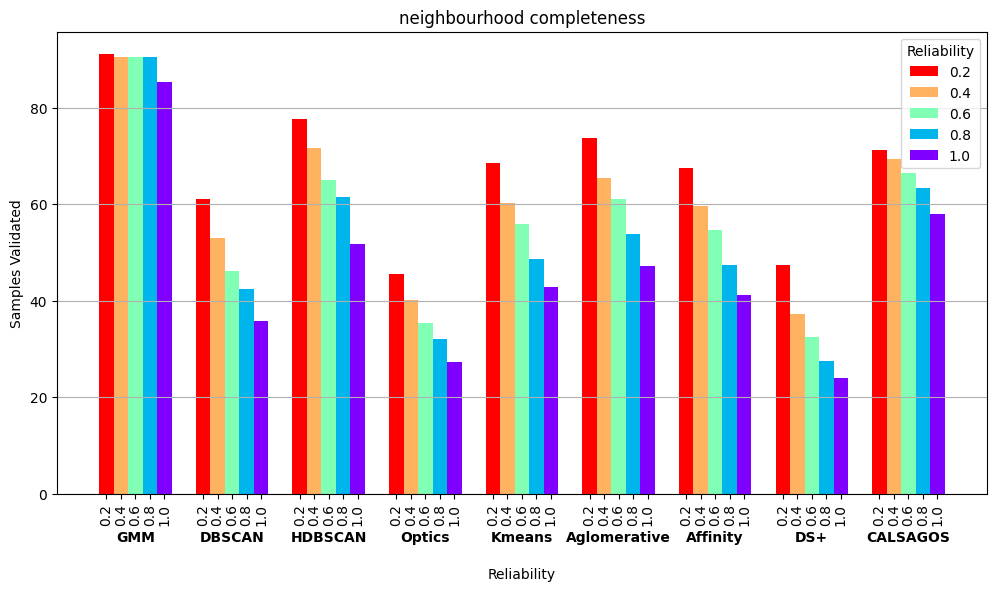

In [56]:
reliability_gradients = []


metric = "neighbourhood completeness"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    reliability_gradients.append(gradient)
    
    
fig, ax = pm.gradients_plot_as_bars(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

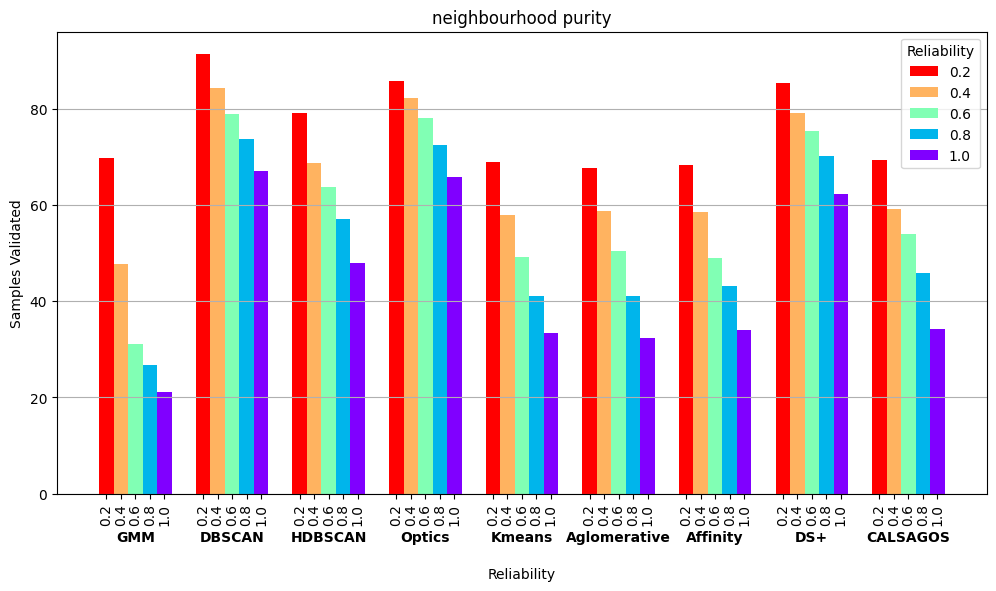

In [57]:
reliability_gradients = []

metric = "neighbourhood purity"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    reliability_gradients.append(gradient)
    
fig, ax = pm.gradients_plot_as_bars(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

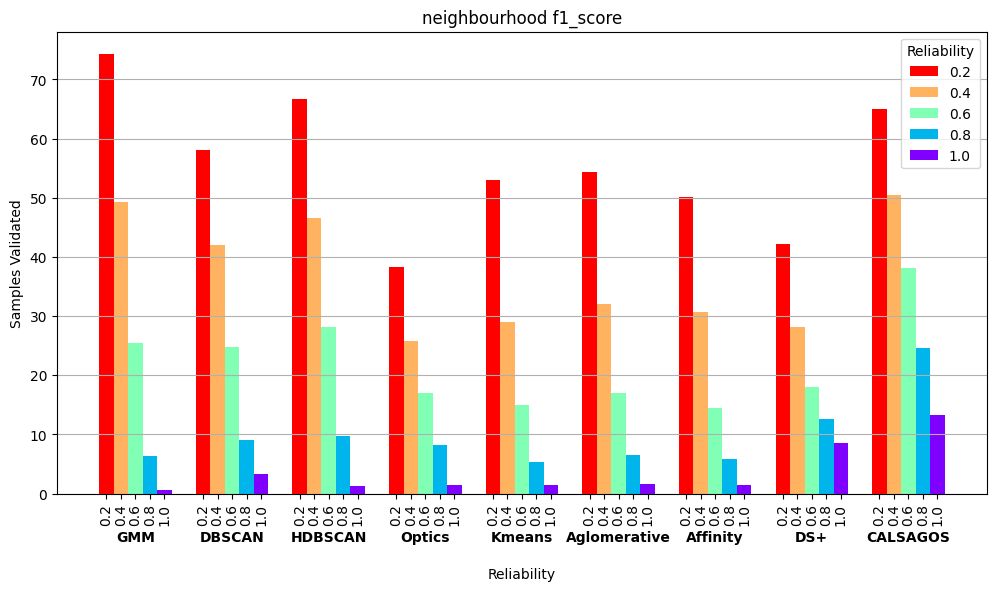

In [58]:
reliability_gradients = []

metric = "neighbourhood f1_score"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    reliability_gradients.append(gradient)
    
fig, ax = pm.gradients_plot_as_bars(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

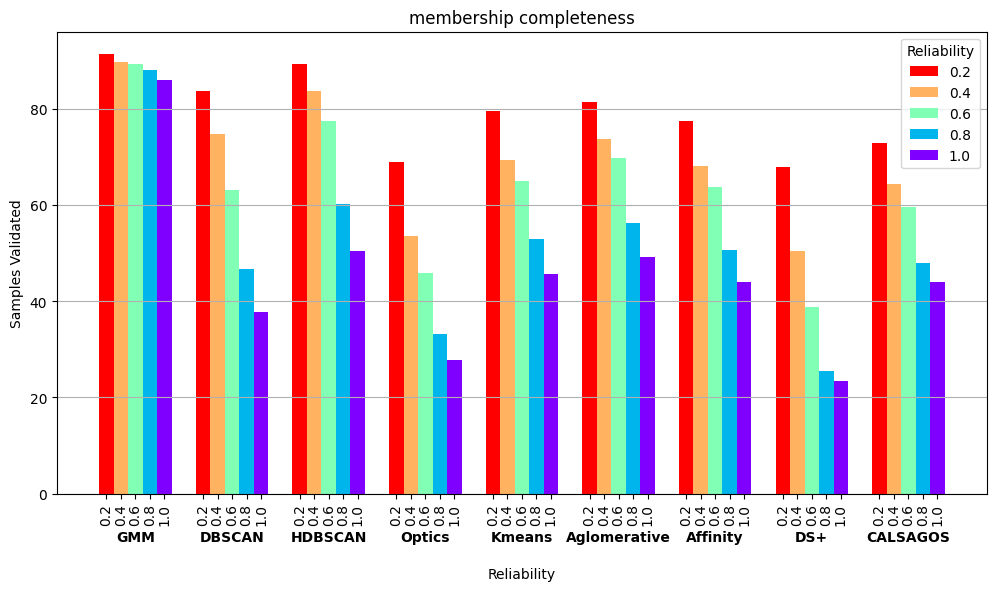

In [60]:
reliability_gradients = []

metric = "membership completeness"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    reliability_gradients.append(gradient)
    
fig, ax = pm.gradients_plot_as_bars(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

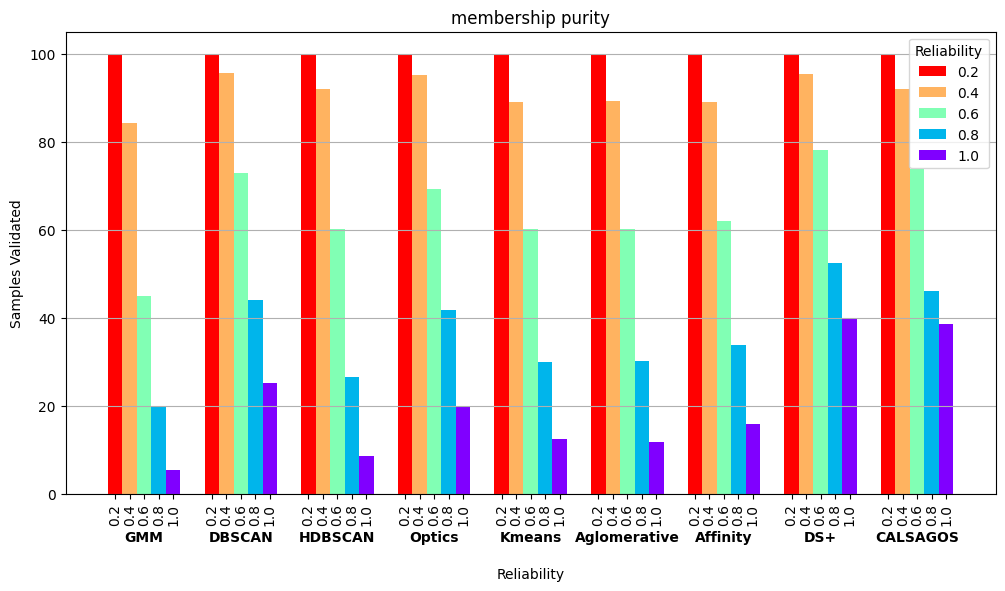

In [59]:
reliability_gradients = []

metric = "membership purity"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    reliability_gradients.append(gradient)
    
fig, ax = pm.gradients_plot_as_bars(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

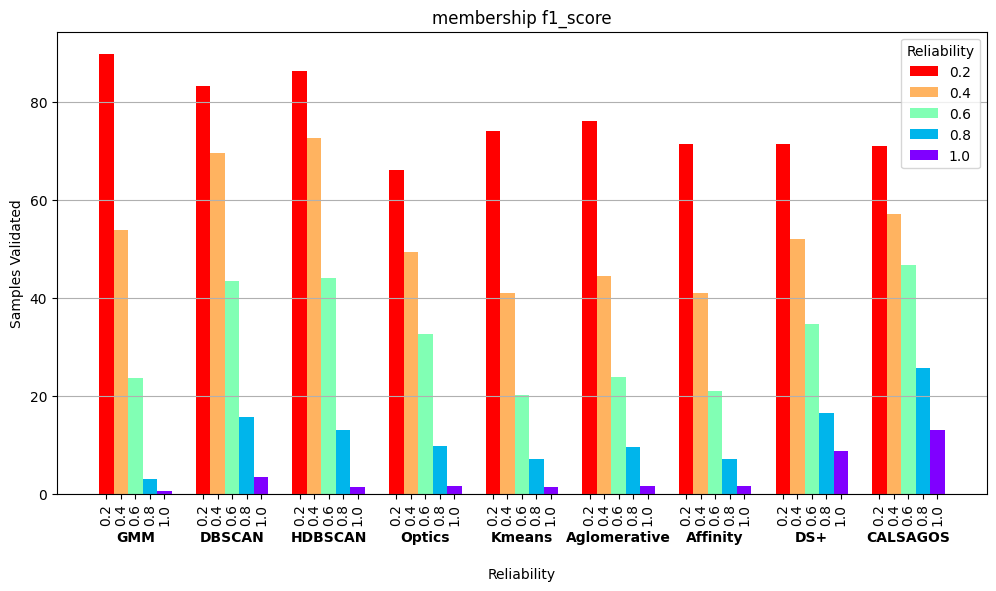

In [61]:
reliability_gradients = []

metric = "membership f1_score"

for alg in alg_labels.keys():
    gradient = cu.reliability_gradient(metrics[metric][alg])
    reliability_gradients.append(gradient)
    
fig, ax = pm.gradients_plot_as_bars(alg_labels.keys(), reliability_gradients, title = metric)

plt.plot

# Plot Clustering Results

# Save Data